In [1]:
import os
import snowflake.connector
import getpass
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from dotenv import load_dotenv

In [2]:
load_dotenv(override=True)

user = os.getenv('SNOWFLAKE_USER')
account = os.getenv('SNOWFLAKE_ACCOUNT')
role = os.getenv('SNOWFLAKE_ROLE')

In [3]:
my_password = getpass.getpass('Snowflake Password: ')

Snowflake Password:  ········


In [4]:
conn = snowflake.connector.connect(
    user=user,
    account=account,
    role=role,
    password=my_password,
    warehouse='COMPUTE_WH',
    database='OLIST_ECOMMERCE',
    schema='ANALYTICS'
)

In [5]:
cursor = conn.cursor()
cursor.execute("SELECT * FROM FCT_ORDERS")

In [6]:
df_orders = cursor.fetch_pandas_all()

In [7]:
cursor.close()
conn.close()

In [8]:
df_orders.head()

,ORDER_ID,CUSTOMER_ID,ORDER_STATUS,ORDER_PURCHASE_AT,TOTAL_ITEMS,TOTAL_PRODUCT_REVENUE,TOTAL_FREIGHT_REVENUE,TOTAL_ORDER_VALUE,TOTAL_PAYMENT_RECEIVED,PRIMARY_PAYMENT_TYPE,IS_UNDERPAID
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,1.0,29.99,8.72,38.71,38.71,voucher,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,1.0,118.70,22.76,141.46,141.46,boleto,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,1.0,159.90,19.22,179.12,179.12,credit_card,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,1.0,45.00,27.20,72.20,72.20,credit_card,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,1.0,19.90,8.72,28.62,28.62,credit_card,False


### KPI

In [9]:
df_orders['ORDER_PURCHASE_AT'] = pd.to_datetime(df_orders['ORDER_PURCHASE_AT'])

In [10]:
total_revenue = df_orders['TOTAL_ORDER_VALUE'].sum()

In [11]:
total_orders = df_orders['ORDER_ID'].nunique()

In [12]:
aov = total_revenue / total_orders if total_orders > 0 else 0

In [13]:
print(f"Total Lifetime Revenue: ${total_revenue:,.2f}")
print(f"Total Orders Processed: {total_orders:,}")
print(f"Average Order Value (AOV): ${aov:,.2f}")

Total Lifetime Revenue: $15,843,553.24
Total Orders Processed: 99,441
Average Order Value (AOV): $159.33


In [14]:
df_successful = df_orders[df_orders['ORDER_STATUS'] != 'canceled'].copy()

In [15]:
df_successful.set_index('ORDER_PURCHASE_AT', inplace=True)

In [16]:
monthly_revenue = df_successful['TOTAL_ORDER_VALUE'].resample('ME').sum()

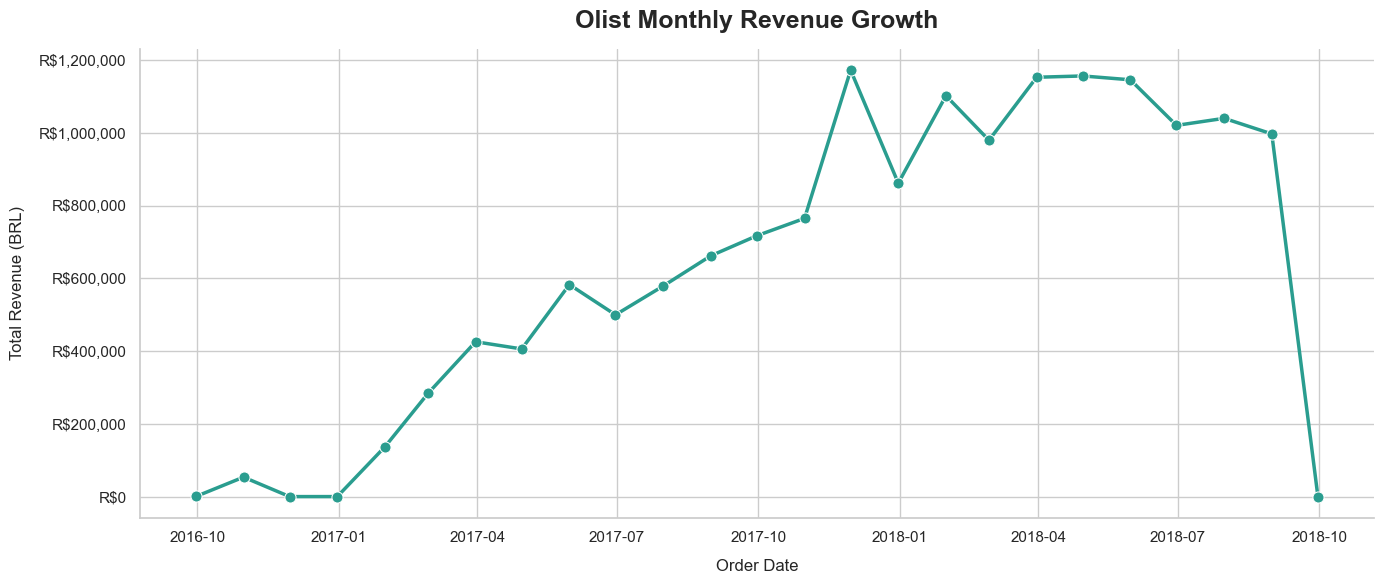

In [17]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    x=monthly_revenue.index, 
    y=monthly_revenue.values, 
    linewidth=2.5, 
    color='#2A9D8F',
    marker='o',
    markersize=8
)

plt.title('Olist Monthly Revenue Growth', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Order Date', fontsize=12, labelpad=10)
plt.ylabel('Total Revenue (BRL)', fontsize=12, labelpad=10)

formatter = ticker.StrMethodFormatter('R${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

sns.despine()
plt.tight_layout()

plt.show()

### Machine Learning (K-means)

In [18]:
snapshot_date = df_orders['ORDER_PURCHASE_AT'].max() + pd.Timedelta(days=1)

In [19]:
rfm = df_orders.groupby('CUSTOMER_ID').agg({
    'ORDER_PURCHASE_AT': lambda x: (snapshot_date - x.max()).days, 
    'ORDER_ID': 'count',                                         
    'TOTAL_ORDER_VALUE': 'sum'                                    
}).reset_index()

In [20]:
rfm.columns = ['CUSTOMER_ID', 'Recency', 'Frequency', 'Monetary']

In [21]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [23]:
cluster_names = {
    0: 'Recent/Average Shoppers',
    1: 'High-Spenders (Whales)',
    2: 'Churned/Lost Customers',
    3: 'Loyal/Frequent Buyers'
}

In [24]:
rfm['Customer_Segment'] = rfm['Cluster'].map(cluster_names)

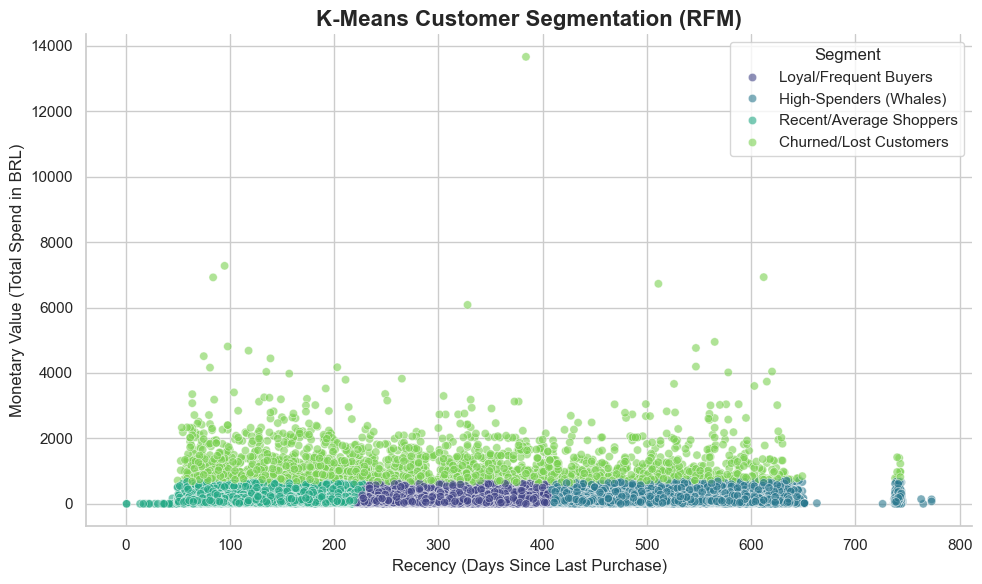

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm, 
    x='Recency', 
    y='Monetary', 
    hue='Customer_Segment',
    palette='viridis', 
    alpha=0.6
)

plt.title('K-Means Customer Segmentation (RFM)', fontsize=16, fontweight='bold')
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Monetary Value (Total Spend in BRL)')
plt.legend(title='Segment')
sns.despine()
plt.tight_layout()
plt.show()

In [26]:
print("AVERAGE METRICS PER CUSTOMER SEGMENT")
display(rfm.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

AVERAGE METRICS PER CUSTOMER SEGMENT


,Recency,Frequency,Monetary
Customer_Segment,,,
Churned/Lost Customers,292.59,1.0,1128.03
High-Spenders (Whales),509.17,1.0,130.69
Loyal/Frequent Buyers,305.39,1.0,128.77
Recent/Average Shoppers,137.23,1.0,136.98
